In [1]:
import sys
import matplotlib.pyplot as plt
import torch
import logging
import pandas as pd
import os
from PIL import Image
import numpy as np
from tqdm import tqdm 

import torch
import torch.nn.functional as F
import numpy as np
from pathlib import Path
import os
import cv2
import pandas as pd
from tqdm import tqdm
import argparse

In [ ]:



def compute_normal_metrics(pred, label, mask, degree_list=[20, 25, 30]):
    """
    Computes the mean and standard deviation of the angular error (in degrees) between
    predicted and ground-truth normals, and also the fraction of valid pixels with errors
    below each threshold specified in degree_list.
    
    Note:
        This function does not perform explicit normalization of the input vectors because
        F.cosine_similarity computes the cosine similarity using the normalized vectors.
    
    Args:
        pred (torch.Tensor): Predicted normals with shape [B, H, W, C].
        label (torch.Tensor): Ground truth normals with shape [B, H, W, C].
        mask (torch.Tensor): Validity mask with shape [B, H, W] or [B, H, W, 1]. Non-zero indicates valid pixels.
        degree_list (iterable): List of angle thresholds (in degrees) for accuracy evaluation.
    
    Returns:
        mean_angle (float): Mean angular error over valid pixels.
        std_angle (float): Standard deviation of angular error over valid pixels.
        degree_acc_list (list of float): List containing the fraction of valid pixels with 
                                         angular error less than each threshold in degree_list.
    """
    # Get dimensions and flatten the spatial dimensions.
    B, H, W, C = pred.size()
    pred_flat = pred.contiguous().view(-1, C)
    label_flat = label.contiguous().view(-1, C)
    mask_flat = mask.view(-1)
    
    # Compute cosine similarity between corresponding vectors.
    # F.cosine_similarity normalizes the inputs internally.
    cos_sim = F.cosine_similarity(pred_flat, label_flat, dim=1, eps=1e-6)
    cos_sim = torch.clamp(cos_sim, -1.0, 1.0)

    # Compute the angular error in degrees.
    angles = (180.0 / np.pi) * torch.acos(cos_sim)

    # Select only valid pixels using the mask.
    valid_angles = angles[mask_flat > 0]

    if valid_angles.numel() > 0:
        # Compute the mean angular error.
        mean_angle = valid_angles.mean().item()
        # Compute the standard deviation of the angular error.
        std_angle = valid_angles.std().item()
        # Compute the fraction (accuracy) of valid pixels with error less than each threshold.
        degree_acc_list = [(valid_angles < d).float().mean().item() for d in degree_list]
    else:
        mean_angle = 0.0
        std_angle = 0.0
        degree_acc_list = [0.0] * len(degree_list)

    return {"mean": mean_angle,
            "std": std_angle, 
            "acc_list": degree_acc_list}

def read_synthesis_depth_png(file_path, threshold=50000):
    """
    Reads a 16-bit grayscale PNG depth image and converts it to a normalized floating-point depth map.
    
    Args:
        file_path (str): Path to the 16-bit PNG depth image.
    
    Returns:
        depth_norm (np.ndarray): Depth values normalized to the [0, 1] range.
    """
    # Read the image with unchanged flag to preserve 16-bit depth
    depth_image = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
    if depth_image is None:
        raise ValueError(f"Failed to load image at {file_path}")
    
    # Verify that the image is indeed 16-bit
    if depth_image.dtype != np.uint16:
        raise ValueError("Image is not 16-bit")
    
    # get mask from depth, max value is invalid depth, set it to 0
    mask = depth_image <=threshold

    # Convert the 16-bit image to floating-point and normalize to [0, 1]
    depth_norm = depth_image.astype(np.float32) / 65535.0
    
    return depth_norm, mask

def change_axis_coordinate(normal):
    tt = np.zeros_like(normal)
    tt[:, :, 0] = normal[:, :, 1]
    tt[:, :, 1] = normal[:, :, 0]
    tt[:, :, 2] = -normal[:, :, 2]
    return tt

def read_synthesis_normal_png(file_path):
    # Open and convert the image to RGB
    normal_image = Image.open(file_path).convert('RGB').resize((512, 512), resample=Image.Resampling.NEAREST)

    # Convert to NumPy array and normalize to [0, 1]
    normal_array = np.array(normal_image).astype(np.float32) / 255.0

    # Split into R, G, B channels
    r = normal_array[:, :, 0]
    g = normal_array[:, :, 1]
    b = normal_array[:, :, 2]

    # Decode to [-1, 1] range
    px = r * 2.0 - 1.0
    py = g * 2.0 - 1.0
    pz = b * 2.0 - 1.0

    # Compute magnitude and normalize
    magnitude = np.sqrt(px**2 + py**2 + pz**2) + 1e-10  # Avoid division by zero
    nx = px / magnitude
    ny = py / magnitude
    nz = pz / magnitude

    # Stack normalized components
    normalized_normal_map = np.stack((nx, ny, nz), axis=2)
    return normalized_normal_map



def cal_photoface_metrics(data_dir, pred_root_dir, test_csv_file, dataset_name="photoface"):
    """
    Evaluate normal estimation results on the dataset.

    Args:
        data_dir (str): Directory containing the dataset.
        pred_dir (str): Directory containing predicted normal maps.
    """

    mean_angle_list = []
    acc_list = []
    std_list = []

    test_data_info = pd.read_csv(test_csv_file, header=None)
    if dataset_name == "synthesis":
        test_data_info.columns = ["image_path", "depth_path", "gt_normal_path"]
    else:
        test_data_info.columns = ["image_path", "depth_path", "gt_normal_path", "mask_path"]

    for index, row in tqdm(test_data_info.iterrows()):
        try:
            np_gt_path = os.path.join(data_dir, row["gt_normal_path"])
            mask_path = os.path.join(data_dir, row["mask_path"])
            np_gt, mask = read_photoface_normal_map(np_gt_path, mask_path)
            np_gt = torch.unsqueeze(torch.from_numpy(-np_gt), 0)
            np_mask = torch.unsqueeze(torch.from_numpy(mask), 0)
            img_path = os.path.join(data_dir, row["image_path"])
            print(img_path)
            np_gt_path = os.path.join(data_dir, row["gt_normal_path"])
            depth_path = os.path.join(data_dir, row["depth_path"])
            identity_dir = "/".join(img_path.split("/")[-3:-1])
            rgb_name_base = Path(img_path).stem
            pred_name_base = rgb_name_base + "_pred"
            pred_path = os.path.join(pred_root_dir, identity_dir, f"{pred_name_base}.npy")
            np_pred = np.load(pred_path)
            np_pred[~mask] = np.array([0., 0., 1.])
            np_pred = torch.unsqueeze(torch.from_numpy(np_pred), 0)
        except Exception as e:
            print("Error: ", e)
            continue
        results = compute_normal_metrics(np_pred, np_gt, np_mask)
        mean_angle_list.append(results["mean"])
        std_list.append(results["std"])
        acc_list.append(results["acc_list"])        
    mean_angle = np.mean(mean_angle_list)
    std_angle = np.mean(std_list)
    acc = np.mean(acc_list, axis=0)
    return mean_angle, std_angle, list(acc)

def  log_photoface_validation(
            vae,
            text_encoder,
            tokenizer,
            unet,
            args,
            scheduler,
            epoch,  
        ):


        # -------------------- Evaluation --------------------
    mean_angle, std_angle, acc = cal_photoface_metrics(input_dir, output_dir_normal_color, csv_file, dataset_name=args.dataset_name)
    # write to file the results
    with open(os.path.join(epoch_output_dir, f"results.txt"), "w") as f:
        f.write(f"Mean Angle: {mean_angle}\n")
        f.write(f"Standard Deviation: {std_angle}\n")
        f.write(f"Accuracy: {list(acc)}\n")

    return mean_angle, std_angle, acc

if __name__=="__main__":
    output_dir_normal_color = "/media/hmi/Transcend/geowizard_checkpoints/validation_results/validation/normal"
    csv_file = '/mnt/hmi/thuong/Photoface_dist/geowizard_photoface_TrainValTest/dataset_0/test.csv'
    mean_angle, std_angle, acc = cal_photoface_metrics("", output_dir_normal_color, csv_file)
    print(mean_angle, std_angle, acc)

In [196]:
def read_photoface_normal_map(normal_path, mask_path):
    normal_map = np.load(normal_path)
    normal_map = change_axis_coordinate(normal_map)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = mask > 128
    normal_map[~mask] = np.array([0., 0., -1.])
    return normal_map, mask
def compute_normal_metrics(pred, label, mask, degree_list=[20, 25, 30]):
    """
    Computes the mean and standard deviation of the angular error (in degrees) between
    predicted and ground-truth normals, and also the fraction of valid pixels with errors
    below each threshold specified in degree_list.
    
    Note:
        This function does not perform explicit normalization of the input vectors because
        F.cosine_similarity computes the cosine similarity using the normalized vectors.
    
    Args:
        pred (torch.Tensor): Predicted normals with shape [B, H, W, C].
        label (torch.Tensor): Ground truth normals with shape [B, H, W, C].
        mask (torch.Tensor): Validity mask with shape [B, H, W] or [B, H, W, 1]. Non-zero indicates valid pixels.
        degree_list (iterable): List of angle thresholds (in degrees) for accuracy evaluation.
    
    Returns:
        mean_angle (float): Mean angular error over valid pixels.
        std_angle (float): Standard deviation of angular error over valid pixels.
        degree_acc_list (list of float): List containing the fraction of valid pixels with 
                                         angular error less than each threshold in degree_list.
    """
    # Get dimensions and flatten the spatial dimensions.
    B, H, W, C = pred.size()
    pred_flat = pred.contiguous().view(-1, C)
    label_flat = label.contiguous().view(-1, C)
    mask_flat = mask.view(-1)
    
    # Compute cosine similarity between corresponding vectors.
    # F.cosine_similarity normalizes the inputs internally.
    cos_sim = F.cosine_similarity(pred_flat, label_flat, dim=1, eps=1e-6)
    cos_sim = torch.clamp(cos_sim, -1.0, 1.0)

    # Compute the angular error in degrees.
    angles = (180.0 / np.pi) * torch.acos(cos_sim)
    angle_reshape = angles.view(1, H, W, 1)
    heatmap = angle_reshape[0, ..., 0].cpu().numpy()  # remove singleton dims, move to NumPy if needed
    
    plt.imshow(heatmap, cmap='hot')  # or 'jet', 'viridis', etc.
    plt.colorbar(label='Angle value')  # optional color scale
    plt.title('Angle Heatmap')         # optional title
    plt.show()
    # Select only valid pixels using the mask.
    valid_angles = angles[mask_flat > 0]

    if valid_angles.numel() > 0:
        # Compute the mean angular error.
        mean_angle = valid_angles.mean().item()
        # Compute the standard deviation of the angular error.
        std_angle = valid_angles.std().item()
        # Compute the fraction (accuracy) of valid pixels with error less than each threshold.
        degree_acc_list = [(valid_angles < d).float().mean().item() for d in degree_list]
    else:
        mean_angle = 0.0
        std_angle = 0.0
        degree_acc_list = [0.0] * len(degree_list)

    return {"mean": mean_angle,
            "std": std_angle, 
            "acc_list": degree_acc_list}


def change_axis_coordinate(normal):
    tt = np.zeros_like(normal)
    tt[:, :, 0] = normal[:, :, 1]
    tt[:, :, 1] = normal[:, :, 0]
    tt[:, :, 2] = -normal[:, :, 2]
    return tt

In [197]:
csv_file = '/mnt/hmi/thuong/Photoface_dist/geowizard_photoface_TrainValTest/dataset_0/test.csv'
test_data_info = pd.read_csv(csv_file, header=None)
test_data_info.columns = ["image_path", "depth_path", "gt_normal_path", "mask_path"]
pred_root_dir = '/media/hmi/Transcend1/geowizard_checkpoints_validation_mask/validation_results/validation/normal/' 

In [214]:
row = test_data_info.iloc[80]

np_gt_path = os.path.join(data_dir, row["gt_normal_path"])
mask_path = os.path.join(data_dir, row["mask_path"])
img_path = os.path.join(data_dir, row["image_path"])
np_gt_path = os.path.join(data_dir, row["gt_normal_path"])
depth_path = os.path.join(data_dir, row["depth_path"])

identity_dir = "/".join(img_path.split("/")[-3:-1])
rgb_name_base = Path(img_path).stem
pred_name_base = rgb_name_base + "_pred"
pred_path = os.path.join(pred_root_dir, identity_dir, f"{pred_name_base}.npy")

np_gt, mask = read_photoface_normal_map(np_gt_path, mask_path)

np_gt, mask = read_photoface_normal_map(np_gt_path, mask_path)
np_gt = torch.unsqueeze(torch.from_numpy(-np_gt), 0)
np_mask = torch.unsqueeze(torch.from_numpy(mask), 0)
np_pred = np.load(pred_path)
np_pred[~mask] = np.array([0., 0., 1.])
np_pred = torch.unsqueeze(torch.from_numpy(np_pred), 0)

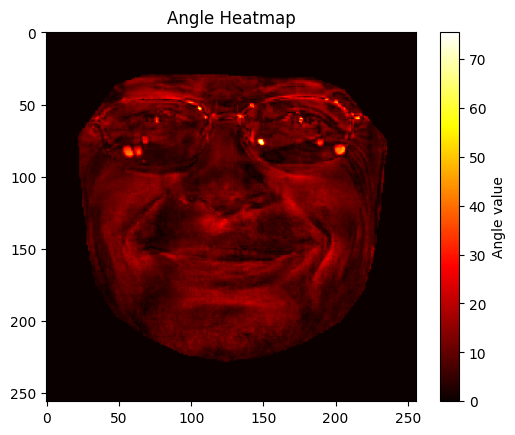

{'mean': 9.112601483438953,
 'std': 4.717428925999699,
 'acc_list': [0.9804109930992126, 0.9918025732040405, 0.9953359365463257]}

In [215]:
res = compute_normal_metrics(np_pred, np_gt, np_mask)
res